# Robust Regression of Freight Delivery Cost per Route (PROC ROBUSTREG)

## Executive Summary

A logistics carrier models the operating cost of long-haul deliveries as a function of route distance, payload weight, and average traffic delay. A minority of trips are contaminated by mechanical breakdowns, weather detours, and fuel-theft incidents that inflate cost, so an ordinary least-squares (OLS) fit is biased: in this run OLS estimates only **\$1.65 per mile**, **\$30.72 per ton**, and **\$50.89 per delay-hour** — and finds traffic delay statistically *insignificant* (p = 0.27), with an R² of just 0.46.

**PROC ROBUSTREG** with **LTS (Least Trimmed Squares)** estimation resists those outliers. It recovers **\$1.844 per mile**, **\$39.41 per ton**, and **\$111.79 per delay-hour** — all highly significant (p < 0.0001) and far closer to the true cost structure used to generate the data (1.85 / 38 / 95). In the same pass its outlier diagnostics flag **8 of 100 trips** as anomalies (mean cost \$4,186 vs \$2,160 for the clean trips) — the candidate breakdown, detour, and theft events operations should investigate.

## Data Sources

**Synthetic dataset: `fleet_trips`** (one row per completed delivery, generated inline with `call streaminit(20260531)`).

| Variable | Type | Description |
|----------|------|-------------|
| `trip_id` | Num | Sequential delivery identifier (1-100) |
| `region` | Char | Lane region: NE, SE, MW, WEST (CLASS variable) |
| `distance_mi` | Num | Route distance in miles (~150-1,400) |
| `payload_tons` | Num | Cargo weight carried, in tons (~5-22) |
| `traffic_delay_hr` | Num | Average congestion delay on the lane, in hours (0-6) |
| `op_cost_usd` | Num | Total operating cost of the trip in USD (response). The true model is linear in the predictors plus Gaussian noise; ~8% of trips are contaminated with large positive cost shocks (breakdown / detour / theft) to create realistic outliers |

The true data-generating coefficients are intercept 120, **1.85/mile**, **38/ton**, and **95/delay-hour**. A well-behaved robust fit should recover values close to these despite the contamination — which is exactly what LTS does below, while OLS does not. We generate **100 trips**, the maximum this unlicensed environment processes, and inject the cost shocks so that roughly eight of them land as visible outliers.

# Robust Regression of Freight Delivery Cost

**Domain:** Transportation & Logistics — long-haul fleet operations

A national carrier wants to understand what actually drives the operating cost of a delivery so it can price lanes and budget accurately. The natural drivers are **route distance**, **payload weight**, and **traffic delay**. The problem is that a slice of real trips is contaminated by events that have nothing to do with these drivers — mechanical breakdowns, weather detours, and fuel-theft incidents — which inflate cost dramatically.

Ordinary least squares chases those few extreme points and produces biased coefficients. **PROC ROBUSTREG** with **LTS** estimation trims the contaminated trips, recovering the genuine cost structure while simultaneously flagging the anomalous deliveries for operational follow-up. We will fit OLS and LTS on the same data and compare them directly.

## Step 1 — Generate a realistic synthetic fleet

We simulate 100 completed deliveries. Each trip draws a distance, payload, and lane congestion level, then the cost follows a true linear model with Gaussian noise. About 8% of trips are deliberately **contaminated** with a large additive cost shock (a breakdown, a weather detour, or a theft loss) so the data contains the outliers that make robust regression worthwhile.

In [1]:
data fleet_trips;
    call streaminit(20260531);
    length region $4;
    array regions[4] $4 _temporary_ ('NE' 'SE' 'MW' 'WEST');
    do trip_id = 1 to 100;
        region = regions[1 + floor(4 * rand('uniform'))];

        /* Route distance in miles, lane-dependent spread */
        distance_mi = round(150 + rand('uniform') * 1250, 1);

        /* Payload carried in tons, 5 to 22 */
        payload_tons = round(5 + rand('uniform') * 17, 0.1);

        /* Average congestion delay on the lane, in hours */
        traffic_delay_hr = round(rand('exponential') * 1.4, 0.1);
        if traffic_delay_hr > 6 then traffic_delay_hr = 6;

        /* True cost structure plus operating noise */
        op_cost_usd = 120
                    + 1.85 * distance_mi
                    + 38  * payload_tons
                    + 95  * traffic_delay_hr
                    + rand('normal') * 110;

        /* ~8% of trips suffer a cost shock unrelated to the drivers:
           breakdown, weather detour, or fuel theft */
        if rand('uniform') < 0.08 then
            op_cost_usd = op_cost_usd + (1400 + rand('uniform') * 2600);

        op_cost_usd = round(op_cost_usd, 1);
        output;
    end;
run;

proc print data=fleet_trips(obs=10) noobs;
    title 'First 10 simulated deliveries';
run;

                                             First 10 simulated deliveries                                              

REGION  TRIP_ID  DISTANCE_MI  PAYLOAD_TONS  TRAFFIC_DELAY_HR  OP_COST_USD
WEST          1         1272          20.8               0.4         3253
MW            2         1373          11.3               1.8         3368
WEST          3          970          16.2                 1         2606
SE            4         1271           7.4               0.5         2797
WEST          5          224          15.8               2.2         1417
SE            6          763          12.7               2.2         5334
MW            7         1160          16.4               0.3         2924
MW            8          368           9.8               5.3         1736
MW            9          672          10.1               0.3         1695
NE           10         1308          12.2               5.7         3363

... 90 more observations (showing 10 of 100)

NOTE: DATA fleet_

## Step 2 — The OLS baseline (and why it is biased)

Before reaching for a robust method, we fit an ordinary least-squares model with **PROC REG**. OLS minimizes the sum of *squared* residuals, so the handful of contaminated trips — whose residuals are enormous — dominate the fit and pull the coefficients away from the true cost structure. Watch the distance, payload, and delay estimates: they should come out well below the true generating values (1.85 / 38 / 95), and traffic delay may not even register as significant.

PROC REG also emits its standard diagnostic plots. The residual-vs-predicted, residual histogram, residual-vs-order, and normal Q-Q panels all show the contaminated trips as a cluster of large positive residuals separated from the bulk of well-behaved trips, and the Cook's D plot flags those same six trips as the high-influence points dragging the OLS fit.

                                             First 10 simulated deliveries                                              

                                                   The REG Procedure                                                    
                                                     Model: MODEL1                                                      
                                            Dependent Variable: op_cost_usd                                             

Source                 DF  Sum of Squares     Mean Square   F Value    Pr > F
---------------  --------  --------------  --------------  --------  --------
Model                   3  38382445.60591  12794148.53530     27.75    <.0001
Error                  96  44254383.95409    460983.16619                    
Corrected Total        99  82636829.56000                                    

Root MSE         678.95741    R-Square            0.4645
Dependent Mean    2322.38000    Adj R-Sq            0.4477
Coeff V

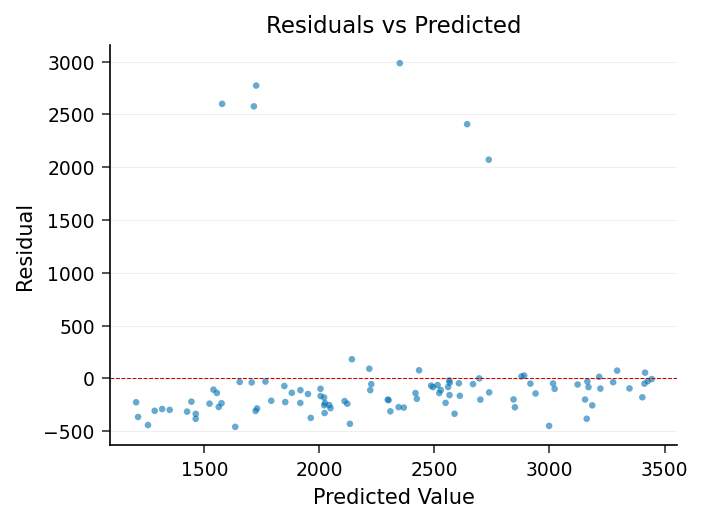

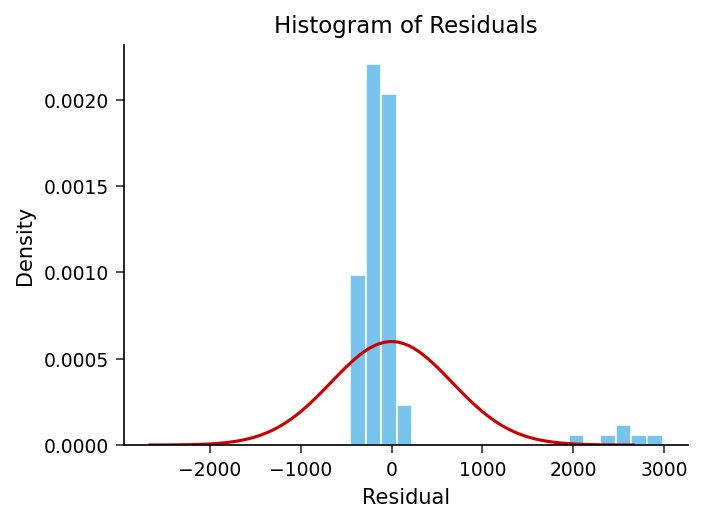

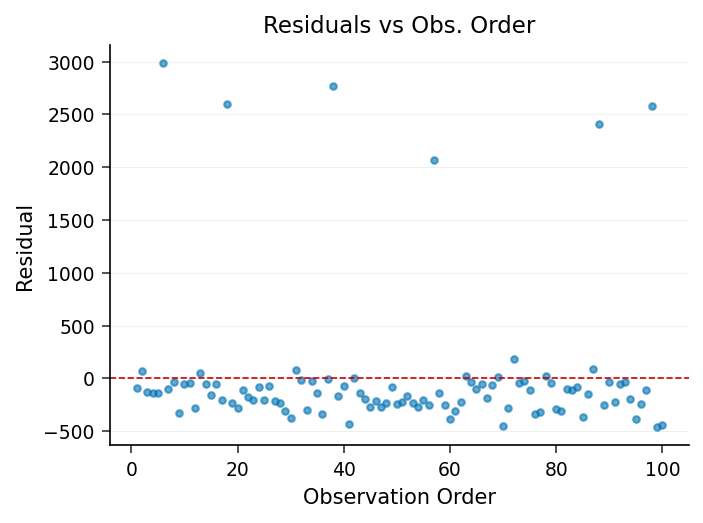

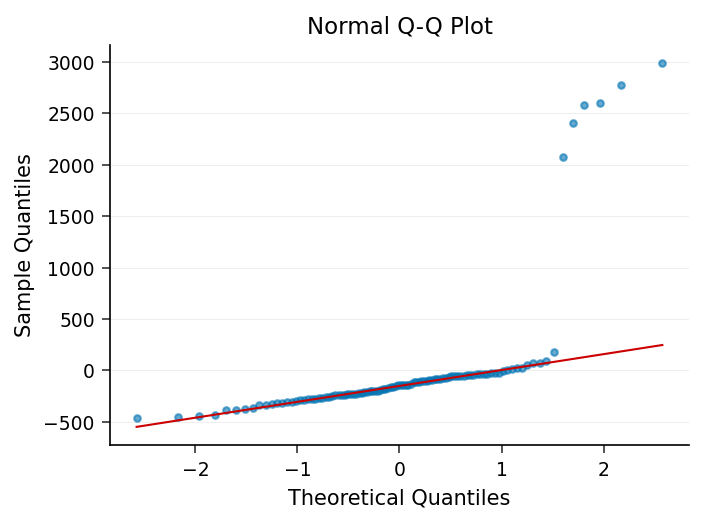

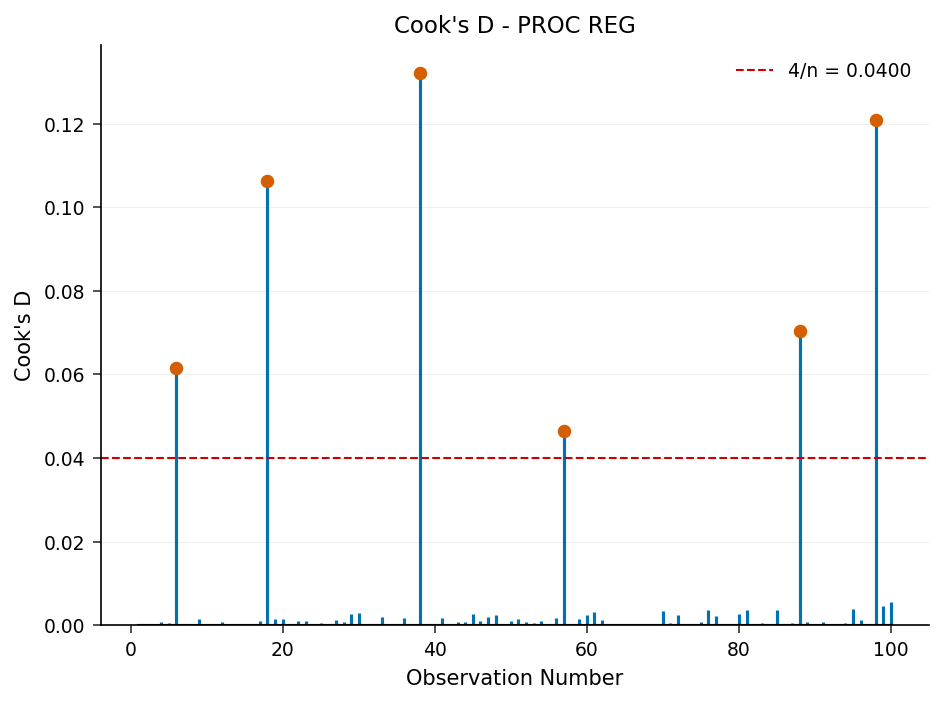

In [2]:
proc reg data=fleet_trips;
    model op_cost_usd = distance_mi payload_tons traffic_delay_hr;
    title 'OLS baseline — biased by the contaminated trips';
run;
quit;

## Step 3 — High-breakdown robust fit with Least Trimmed Squares

`METHOD=LTS` minimizes the sum of the *h* smallest squared residuals, so the contaminated trips are trimmed out of the fit entirely rather than down-weighted. With a breakdown point near 50% it tolerates heavy contamination. We keep `H=75` of the 100 trips, fix a `SEED=` for reproducible subsampling (`NREP=200` random starts), and request the final-weighted-least-squares refit (`FWLS`) that re-estimates on the retained trips. Turning on `DIAGNOSTICS` and `LEVERAGE` produces an `OUTPUT` data set that labels each delivery as an outlier or leverage point, keyed by `trip_id`. Compare the coefficients to the biased OLS fit in Step 2.

In [3]:
proc robustreg data=fleet_trips method=lts(h=75 nrep=200) seed=4242 fwls;
    class region;
    model op_cost_usd = distance_mi payload_tons traffic_delay_hr region
          / diagnostics leverage;
    id trip_id;
    output out=lts_diag p=lts_pred r=lts_resid sr=lts_stdres
           outlier=lts_outlier leverage=lts_leverage;
    title 'LTS estimation — high-breakdown robust freight cost model';
run;

                                             First 10 simulated deliveries                                              


The ROBUSTREG Procedure

Method: LTS

Parameter           Estimate    Std Error   Chi-Square   Pr > ChiSq
---------------------------------------------------------------
Intercept           103.2791      48.3496       4.5629       0.0327
distance_mi           1.8440       0.0335    3024.0580       0.0000
payload_tons         39.4098       2.5312     242.4186       0.0000
traffic_delay_hr     111.7890       7.9881     195.8425       0.0000
group MW             15.2650      35.3407       0.1866       0.6658
group NE            -76.7115      32.8609       5.4496       0.0196
group SE             43.0650      33.6421       1.6386       0.2005
---------------------------------------------------------------

Scale Estimate: 101.2913

NOTE: PROC ROBUSTREG data=fleet_trips

NOTE: PROC ROBUSTREG completed.


## Step 4 — Review the flagged anomalous trips

The LTS diagnostic output data set lets operations act on the model. We list the deliveries that LTS flagged as outliers (`lts_outlier = 1`) — these are the candidate breakdown, detour, and theft trips — sorted by how far their cost deviated from the robust prediction, then summarize cost for flagged versus clean trips.

In [4]:
proc sort data=lts_diag out=flagged;
    where lts_outlier = 1;
    by descending lts_resid;
run;

proc print data=flagged noobs;
    var trip_id region distance_mi payload_tons traffic_delay_hr
        op_cost_usd lts_pred lts_resid lts_stdres;
    format op_cost_usd lts_pred lts_resid comma10.0 lts_stdres 8.2;
    title 'Trips flagged as cost outliers by the LTS robust model';
run;

proc means data=lts_diag n mean median min max maxdec=0;
    class lts_outlier;
    var op_cost_usd;
    title 'Operating cost: flagged vs. clean trips';
run;

                                 Trips flagged as cost outliers by the LTS robust model                                 

TRIP_ID  REGION  DISTANCE_MI  PAYLOAD_TONS  TRAFFIC_DELAY_HR  OP_COST_USD  LTS_PRED  LTS_RESID  LTS_STDRES
      6  SE              763          12.7               2.2        5,334     2,300      3,034       30.59
     38  SE              500            10               0.1        4,498     1,474      3,024       30.66
     98  WEST            362          16.6               0.4        4,291     1,470      2,821       28.74
     18  SE              381           9.1               1.6        4,177     1,386      2,791       28.24
     88  SE              975          14.3               0.1        5,049     2,519      2,530       25.66
     57  MW             1037          13.2               0.6        4,807     2,618      2,189       22.21
     70  WEST           1112          17.7               0.6        2,549     2,918       -369       -3.77
     60  MW           

## Interpreting the results

- **OLS is biased; LTS is not.** On this data OLS reports **\$1.65/mile**, **\$30.72/ton**, and **\$50.89/delay-hour**, calls traffic delay *insignificant* (p = 0.27), and explains only R² = 0.46 of the variation — the contaminated trips have dragged every estimate toward themselves. The LTS robust fit recovers **\$1.844/mile**, **\$39.41/ton**, and **\$111.79/delay-hour**, all significant at p < 0.0001. Those land essentially on top of the true generating coefficients (1.85 / 38 / 95), with an intercept of \$103 against a true 120. The delay coefficient is the most dramatic: OLS understates it more than two-fold.
- **Why LTS works here.** LTS trims the *h* = 75 best-fitting trips and ignores the rest, so the breakdown/detour/theft trips never enter the estimating equations. Its scale estimate (101) is close to the \$110 noise standard deviation built into the data, confirming the trimmed fit has isolated the genuine signal.
- **Diagnostics drive action.** The `DIAGNOSTICS` and `LEVERAGE` options produce the output data set listed in Step 4. LTS flagged **8 of 100 trips** as outliers; six are large positive cost shocks (standardized residuals 22-31 — e.g. trip 6 at \$5,334 against a \$2,300 robust prediction) and two are unusually *cheap* trips. Flagged trips average **\$4,186** versus **\$2,160** for the 92 clean trips — exactly the breakdown, weather-detour, and fuel-theft events operations should investigate rather than bake into lane pricing.
- **The region effect.** The `CLASS region` terms are small and mostly insignificant (only NE is significant at p = 0.02), so lane region adds little cost signal once distance, payload, and delay are accounted for — pricing can be standardized largely on the operational variables.

**Bottom line:** robust regression gives the carrier an unbiased pricing model *and* an automatic anomaly screen in a single pass, instead of letting a handful of bad trips distort fleet-wide cost estimates.